# Data Overview and Market Statistics

This notebook builds the foundational data object for the entire project: the **return matrix** $R \in M_{T \times N}(\mathbb{R})$, where each row is a month and each column is a stock. Everything that follows in the sequals is essentially a linear algebra operation on this matrix or its covariance matrix $\Sigma = \frac{1}{T-1}X_c^TX_c$.

The main goals of this notebook are as follows.
1. To assemble a clean survivorship-aware univerise of US large-cap equities (the columns of our return matrix $R$).
2. To build the return panel (fill in the matrix) from freely available price data.
3. To identify broad trends in cross-sectional dispesion, sector composition, and turnover. 
4. To create a clean descriptive baseline fo the later factor and backtest notebooks. 

### Finance terms used in this notebook

| Term | Meaning |
|------|---------|
| **Return** | Fractional price change: $r_{t} = p_t / p_{t-1} - 1$ |
| **Return panel** $\mathbf{R}$ | The $T \times N$ matrix of monthly returns — months (rows) $\times$ stocks (columns); the project's central object |
| **Cross-section** | A row of $\mathbf{R}$ — all stocks at one date |
| **One stock's history** | A column of $\mathbf{R}$ |
| **Universe** | The set of stocks (columns) we're allowed to hold — here the S&P 500 |
| **Sector** | A categorical partition of stocks (Technology, Financials, …); a 0,1 matrix $\mathbf{D}$ |
| **Dispersion** | Cross-sectional standard deviation — how spread out returns are across a row |
| **Equal-weight index** | Mean of a row $\bar{r}_t = \tfrac{1}{N_t}\mathbf{1}^\top r_t$ (every stock at weight $w_i = 1/N_t$) |
| **Sharpe ratio** | Mean return / volatility — a signal-to-noise ratio (computed here for the equal-weight index) |
| **Survivorship bias** | Only stocks that *survived* until today appear; delisted names are missing, biasing returns upward |

Throughout, I treat each stock-month as a separate observation unless explicitly noted otherwise. That matters because the universe changes over time — names enter and leave the index — so the matrix $\mathbf{R}$ is *sparse* (has NaN entries) wherever a stock didn't trade yet or was delisted.

## Outputs

We produce a cleaned monthly return panel ($R$), a sector mapping table, and exploratory plots that motivate later notebooks. Topics include:
- single-factor diagnostics (vectors $f_t$ that predict rows of $R$),
- composite signal construction (linear combinations of orthogonalized factor vectors),
- backtesting (weight vectors $w$ and portfolio returns $w^Tr)$,
- risk decomposition (eigendecomposition of the covariance matrix $\Sigma$). 

## Notebook Structure
1. [Setup and Imports](#setup-and-imports)
2. [Universe Construction](#universe-construction)
3. [Return Panel Assembly](#return-panel-assembly)
4. [Market Statistics](#market-statistics)
5. [Sector Composition](#sector-composition)
6. [Conclusion](#conclusion)

## Setup and Imports

In [1]:
"""
==================================
Setup and imports
==================================
"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import os
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

palette = ['steelblue', 'coral', 'seagreen']

os.makedirs('../data/raw', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../images/01_market_stats', exist_ok=True)

START_DATE = '2005-01-01'
END_DATE = '2025-12-31'
RANDOM_STATE = 3

## Universe Construction

We use the S&P 500 current constituents as a starting list and pull price history for each. This introduces **survivorship bias** (i.e., names that went bankrupt or were delisted between 2005 and today won't appear). In linear-algebraic terms, the columns of our return matrix $R$ are a non-random subset of all stocks that existed; the columns we don't see are exactly the ones that went to zero, which biases our return estimates upward. This can be properly handled with different data, but we work with this as is for the sake of simplicity. 

In [2]:
"""
==================================
Pull S&P 500 constituents from Wikipedia
==================================
"""

import requests
from io import StringIO

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Wikipedia requires a descriptive User-Agent per their API policy
headers = {
    'User-Agent': 'EquityFactorResearch/1.0 (quant research; contact@example.com)'
}

resp = requests.get(url, headers=headers)
resp.raise_for_status()

# match='Symbol' targets the constituents table directly
tables = pd.read_html(StringIO(resp.text), match='Symbol')
df_constituents = tables[0]

df_constituents['Symbol'] = df_constituents['Symbol'].str.replace('.', '-', regex=False)
tickers = df_constituents['Symbol'].tolist()

df_constituents.to_csv('../data/raw/constituents.csv')

print(f"Total constituents: {len(tickers)}")
print(f"First 10: {tickers[:10]}")
df_constituents.head()


Total constituents: 503
First 10: ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


A note on the CIK: CIK stands for **Central Index Key**. It's a unique identifier assigned by the U.S. Securities and Exchange Commission (SEC) to every entity (company, individual, or organization) that files disclosure documents with them.

In [3]:
"""
==================================
Download price history via yfinance
==================================

We use adjusted close to account for splits
and dividends, then resample to monthly returns.
"""
from tqdm import tqdm # progress bar

raw_path = '../data/raw/prices_monthly.csv'

if os.path.exists(raw_path):
    print(f"Loading cached prices from {raw_path}")
    df_prices = pd.read_csv(raw_path, index_col=0, parse_dates=True)
else:
    print(f"Downloading price data for {len(tickers)} tickers ...")
    df_raw = yf.download(
        tickers,
        start=START_DATE,
        end=END_DATE,
        progress=True,
        auto_adjust=True,
        threads=True
    )

    # Use adjusted close
    df_prices = df_raw['Close']
    df_prices.to_csv(raw_path)
    print(f"Saved to {raw_path}")

print(f"\nPrice panel shape: {df_prices.shape}")
print(f"Date range: {df_prices.index.min()} to {df_prices.index.max()}")


[******************    37%                       ]  188 of 503 completed$HONA: possibly delisted; no price data found  (1d 2005-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1767157200")
[*******************   39%                       ]  196 of 503 completed$FDXF: possibly delisted; no price data found  (1d 2005-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1767157200")
[*********************100%***********************]  503 of 503 completed

2 Failed downloads:
['HONA', 'FDXF']: possibly delisted; no price data found  (1d 2005-01-01 -> 2025-12-31) (Yahoo error = "Data doesn't exist for startDate = 1104555600, endDate = 1767157200")


Saved to ../data/raw/prices_monthly.csv

Price panel shape: (5282, 503)
Date range: 2005-01-03 00:00:00 to 2025-12-30 00:00:00


## Return Panel Assembly

We resample daily prices to month-end and compute simple monthly return 
$$ r_{t,i} = p_{t,i}/p_{t-1,i} - 1. $$
Here $t$ is the time index, $i$ is the stock index, and $p_{t,i}$ is the closing date. The ratio $p_{t,i}/p_{t-1,i}$ tells us what \$1 invested ends up as, so we subtract 1 in order to get the simple net return. 

The result is the return matrix $R \in M_{T \times N}(\mathbb{R})$ with months as rows and stocks as columns. 

We are working with month-end for both simplicity, and the fact that a daily rebalance would contribute to large $\ell^1$ distances between consecutive weights.

In [4]:
"""
==================================
Build monthly return panel
==================================
"""
# Resample to month-end and compute returns
df_monthly_prices = df_prices.resample('ME').last()
df_returns = df_monthly_prices.pct_change() # fractional change between current and prior

# Drop the first row (NaN from pct_change)
df_returns = df_returns.iloc[1:]

# Drop columns that are entirely NaN (delisted / no data)
df_returns = df_returns.dropna(axis=1, how='all')

print(f"Montly return panel shape: {df_returns.shape}")
print(f"Date range: {df_returns.index.min()} to {df_returns.index.max()}")
print(f"Unique tickers: {df_returns.shape[1]}")

df_returns.iloc[:5,:5]

Montly return panel shape: (251, 501)
Date range: 2005-02-28 00:00:00 to 2025-12-31 00:00:00
Unique tickers: 501


Ticker,A,AAPL,ABBV,ABNB,ABT
Date,,,,,
2005-02-28,0.085482,0.166711,NaN,NaN,0.021546
2005-03-31,-0.075000,-0.071111,NaN,NaN,0.013699
2005-04-30,-0.065315,-0.134629,NaN,NaN,0.060572
2005-05-31,0.157109,0.102606,NaN,NaN,-0.018714
2005-06-30,-0.041233,-0.074195,NaN,NaN,0.015962


In [5]:
"""
==================================
Save return panel
==================================
"""
df_returns.to_csv('../data/processed/returns_monthly.csv')
df_monthly_prices.to_csv('../data/processed/prices_monthly.csv')

print("Saved:")
print("  - ../data/processed/returns_monthly.csv")
print("  - ../data/processed/prices_monthly.csv")

Saved:
  - ../data/processed/returns_monthly.csv
  - ../data/processed/prices_monthly.csv


## Market Statistics

Let's get a feel for the market itself.
- How many columns are available each month? We'll call this `breadth`, but this really counts how many of today's survivors had valid prices at month $t$. As we have ~501 stocks at 2025-12, this means that ~116 stocks from 2005 have been replaced with different ones. 
- What does cross-sectional dispersion look like (the standard deviation across each row of $R$)?
$$ \sigma_t^{XS} = \sqrt{\frac{1}{N_t - 1} \sum_{i=1}^{N_t}(r_{t,i} - \bar{r}_t)^2} $$
- How does the equal-weight market index behave? The equal-weight market index return at month $t$ is simply the mean of the row: $\bar{r}_t = \frac{1}{N_t} \mathbf{1}^\top r_t$, where $\mathbf{1}$ is the all ones vector and $N_t$ is the number of stocks alive at date $t$. This is the return of a portfolio that holds every stock at equal weight $w_i = \frac{1}{N_t}$. 


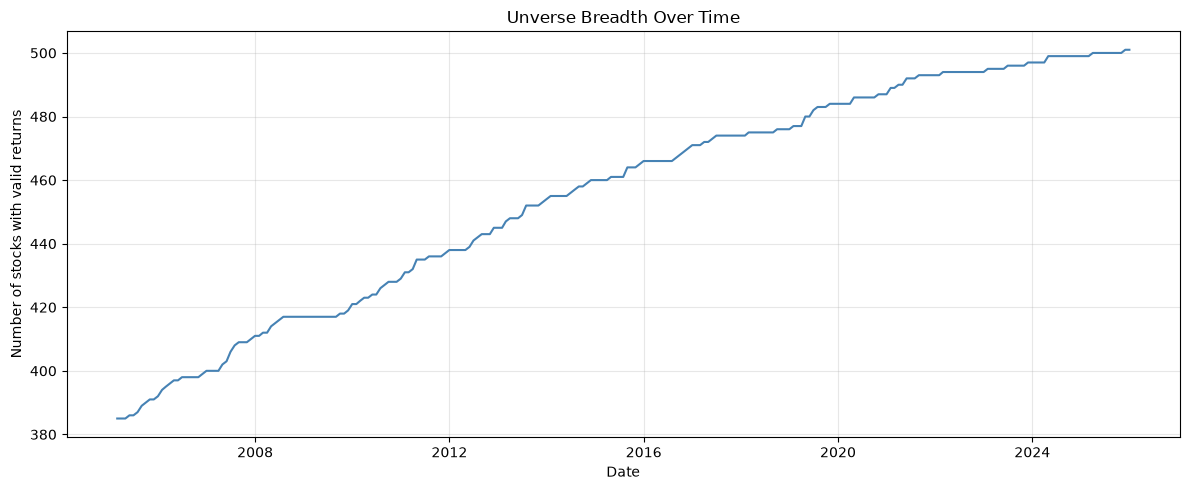

Average breadth: 455
Min breadth: 385
Max breadth: 501


In [6]:
"""
==================================
Universe breadth over time
==================================
"""
# Count non-NaN returns each month
universe_breadth = df_returns.notna().sum(axis=1)

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(universe_breadth.index, universe_breadth.values, color='steelblue')
ax.set_xlabel('Date')
ax.set_ylabel('Number of stocks with valid returns')
ax.set_title('Unverse Breadth Over Time')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_market_stats/universe_breadth.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average breadth: {universe_breadth.mean():.0f}")
print(f"Min breadth: {universe_breadth.min()}")
print(f"Max breadth: {universe_breadth.max()}")

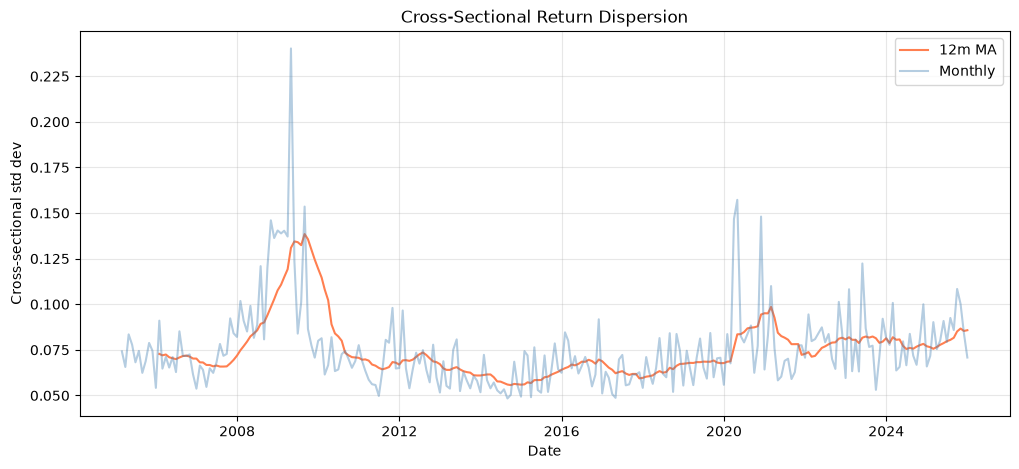

Average monthly CS dispersion: 0.0754
Annualized: 0.2610


In [7]:
"""
==================================
Cross-sectional return dispersion
==================================
"""
# Cross-sectional standard deviation each month
cs_dispersion = df_returns.std(axis=1)

fig,ax = plt.subplots(figsize=(12,5))
ax.plot(cs_dispersion.index, cs_dispersion.rolling(12).mean(), color='coral', label='12m MA') # this smooths the last 12 months
ax.plot(cs_dispersion.index, cs_dispersion, color='steelblue', alpha=0.4, label='Monthly')
ax.set_xlabel('Date')
ax.set_ylabel('Cross-sectional std dev')
ax.set_title('Cross-Sectional Return Dispersion')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout
plt.savefig('../images/01_market_stats/cs_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average monthly CS dispersion: {cs_dispersion.mean():.4f}")
print(f"Annualized: {cs_dispersion. mean() * np.sqrt(12):.4f}")

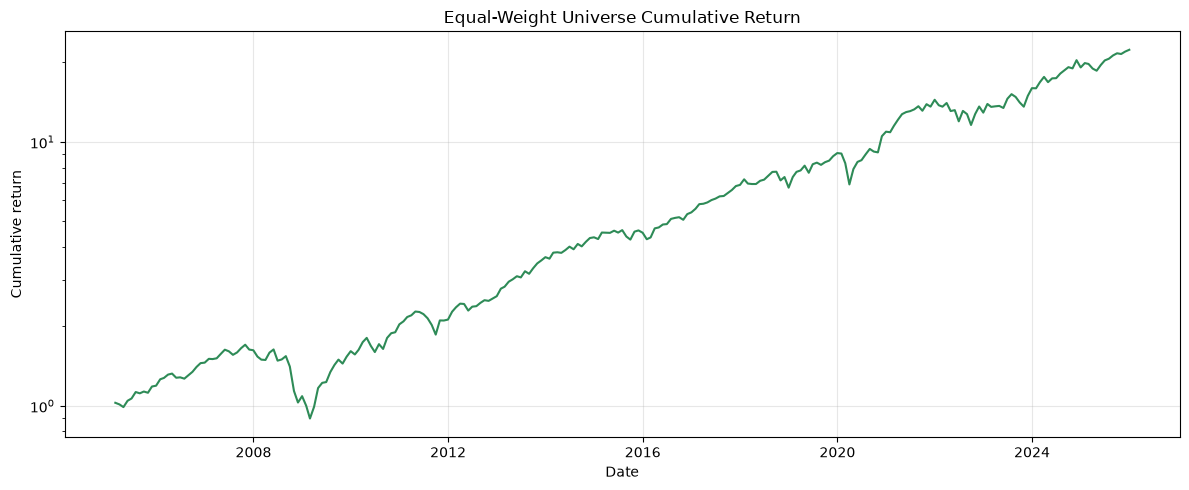

Annualized return: 0.1632
Annualized vol: 0.1659
Sharpe (rf=0): 0.984


In [8]:
"""
==================================
Equal-weight market index
==================================
"""
ew_market = df_returns.mean(axis=1)
cum_ew = (1 + ew_market).cumprod()
"""
Mathematically, .cumprod() will do the following:
W_t = prod_{s=1}^t (1 + bar{r}_s) with W_0 = 1
"""

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(cum_ew.index, cum_ew.values, color='seagreen')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative return')
ax.set_title('Equal-Weight Universe Cumulative Return')
ax.set_yscale('log')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/01_market_stats/ew_market_cumulative.png', dpi = 150, bbox_inches='tight')
plt.show()

ann_return = ew_market.mean() * 12
ann_vol = ew_market.std() * np.sqrt(12)
sharpe = ann_return / ann_vol

print(f"Annualized return: {ann_return:.4f}")
print(f"Annualized vol: {ann_vol:.4f}")
print(f"Sharpe (rf=0): {sharpe:.3f}")

## Sector Composition

Sectors are a categorical partition of the column index — each stock belongs to exactly one of the ~11 sectors (Technology, Financials, Healthcare, etc.). A binary encoding of sector membership gives a $\{0,1\}$ $N \times K$ matrix that will reappear in later notebooks. 

Sectors matter for two reasons. First, many factors (value, quality) have strong sector tilts that need to be projected out if we want a clean understanding of what is happening. Second, sector concentration in the universe drives how much idiosyncratic risk (stock-specific variance) a long-short portfolio will carry.

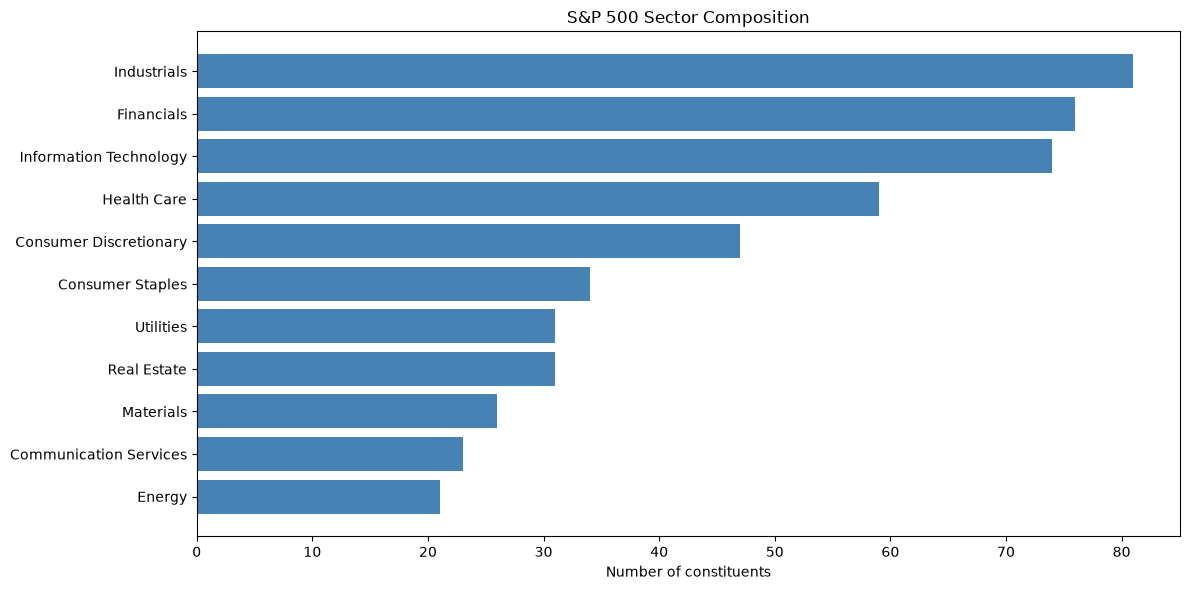

,count
sector,
Industrials,81
Financials,76
Information Technology,74
Health Care,59
Consumer Discretionary,47
Consumer Staples,34
Utilities,31
Real Estate,31
Materials,26


In [9]:
"""
==================================
Sector mapping
==================================
"""
# Use GICS sector from the constituents table
df_sector = df_constituents[['Symbol', 'GICS Sector']].copy()
df_sector.columns = ['ticker', 'sector']
df_sector = df_sector.dropna(subset=['sector'])

# Save for later
df_sector.to_csv('../data/processed/sector_mapping.csv', index=False)

sector_counts = df_sector['sector'].value_counts()

fig,ax = plt.subplots(figsize=(12,6))
ax.barh(sector_counts.index, sector_counts.values, color='steelblue')
ax.set_xlabel('Number of constituents')
ax.set_title('S&P 500 Sector Composition')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../images/01_market_stats/sector_composition.png', dpi=150, bbox_inches='tight')
plt.show()

display(sector_counts.to_frame('count'))


## Conclusion

We have our return matrix $R$, which is a clean monthly panel over ~500 US large-cap stocks from 2005 to 2025, along with some valuable statistics and a sector mapping. In the next notebook, we take this matrix $R$ and ask the first factor question: which vectors $f_t \in \mathbb{R}^{N_t}$ have meaningful cross-sectional predictive power (i.e., point in roughly the same direction as the next month's return vector $r_{t+1}$), and how do they behave over time?